# odor_space_sampling — Quickstart

This notebook shows the simplest way to use this package. Everything you need is importable directly from `odor_space_sampling` — you don't need to worry about the individual submodules.

The typical workflow is three steps:
1. **Load** your data
2. **Sample** odors from the space
3. **Visualize** how the samples cover the space

## Step 1 — Load your data

`load_and_prepare` takes a path to a CSV file (which must have a `smiles` column) and returns a `data` object that bundles everything together. Under the hood it computes RDKit descriptors, removes bad features, and reduces the dimensionality with PCA.

In [2]:
from odor_space_sampling import load_and_prepare

data = load_and_prepare("../data/gslf_and_human_data.csv")

# data.df  → the original table of molecules (smiles, label, cid, IUPAC, ...)
# data.x   → the processed numeric matrix used for sampling
print(f"{len(data.df)} odors loaded")
print(data.df.head())

generating descriptors: 100%|██████████| 5841/5841 [00:17<00:00, 335.13it/s]

initial data shape: (5841, 205)
dimension after removing constant features: (5841, 193)
dimensionality of 99% explained variance: 107
reduced space shape (5841, 107)
5841 odors loaded
                smiles     label    cid                    IUPAC
0      Cc1ccnc2ccccc12  ['gslf']  10285        4-methylquinoline
1  CC(C)c1ccnc2ccccc12  ['gslf']  74004     4-isopropylquinoline
2      Cc1cnc2ccccc2n1  ['gslf']  23686      2-methylquinoxaline
3     Cc1nc2ccccc2nc1C  ['gslf']  16925  2,3-dimethylquinoxaline
4      Cc1cccc2nccnc12  ['gslf']  61670      5-methylquinoxaline


## Adding CID and IUPAC names

If your CSV doesn't have PubChem CIDs or IUPAC names yet, `add_cid_to_data` will query PubChem and add them. It takes a path to a CSV file (with a `smiles` column) and returns an enriched dataframe.

**Note:** This queries the PubChem API once per molecule, so it can be slow for large datasets.

In [6]:
from odor_space_sampling import add_cid_to_data

# save a small subset without CID/IUPAC to demonstrate enrichment
cid_example_fp = "../data/no_cid_test.csv"
sampled_no_cid = data.df[["smiles", "label"]].head(5)

print("csv before")
print(sampled_no_cid)

sampled_no_cid.to_csv(cid_example_fp, index=False)

# add CID and IUPAC names from PubChem
enriched = add_cid_to_data(
    cid_example_fp,
    save=False  # If you want to overwrite the csv with CID and IPUAC info, set this to True
)

print("csv after")
print(enriched)

csv before
                smiles     label
0      Cc1ccnc2ccccc12  ['gslf']
1  CC(C)c1ccnc2ccccc12  ['gslf']
2      Cc1cnc2ccccc2n1  ['gslf']
3     Cc1nc2ccccc2nc1C  ['gslf']
4      Cc1cccc2nccnc12  ['gslf']


generating CIDs: 5it [00:02,  2.21it/s]

csv after
                smiles     label    cid                    IUPAC
0      Cc1ccnc2ccccc12  ['gslf']  10285        4-methylquinoline
1  CC(C)c1ccnc2ccccc12  ['gslf']  74004     4-isopropylquinoline
2      Cc1cnc2ccccc2n1  ['gslf']  23686      2-methylquinoxaline
3     Cc1nc2ccccc2nc1C  ['gslf']  16925  2,3-dimethylquinoxaline
4      Cc1cccc2nccnc12  ['gslf']  61670      5-methylquinoxaline


## Step 2 — Sample odors

`sample_with_all_methods` runs every sampling strategy at once and returns a dictionary. Each key is a method name and each value contains the sampled molecules, their indices into the original dataset, and distances.

In [7]:
from odor_space_sampling import sample_with_all_methods

results = sample_with_all_methods(data, n_samples=100, seed=12345)

print("Sampling methods run:", list(results.keys()))

Sampling methods run: ['uniform', 'LHS', 'gaussian', 'min_max', 'kmeans', 'gmm']


## Step 3 — Visualize the samples

`plot_all_sampling_methods` projects the full odor space into 2D (using PCA and UMAP) and shows where each sampling method placed its points. Grey dots are all odors; red dots are the selected samples.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


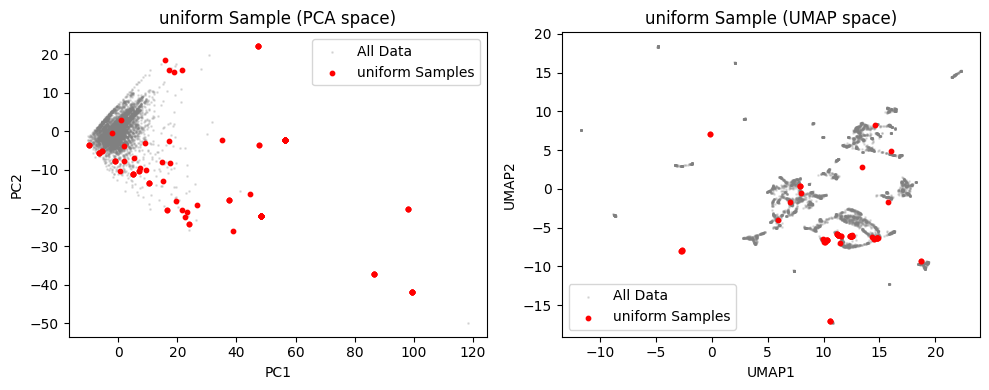

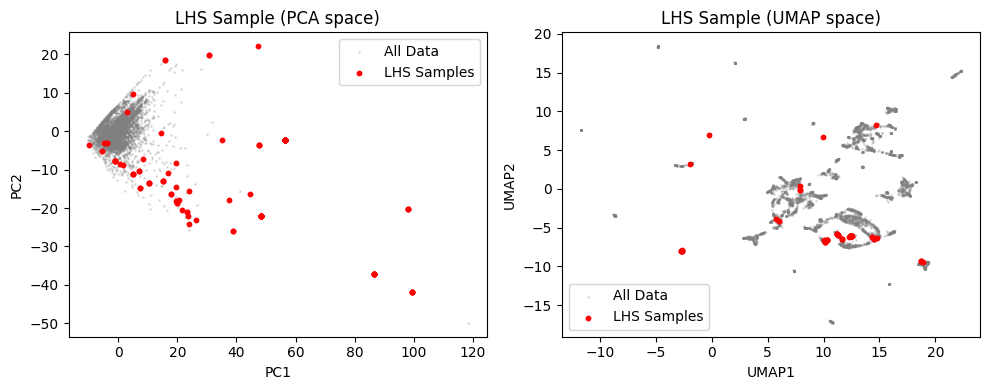

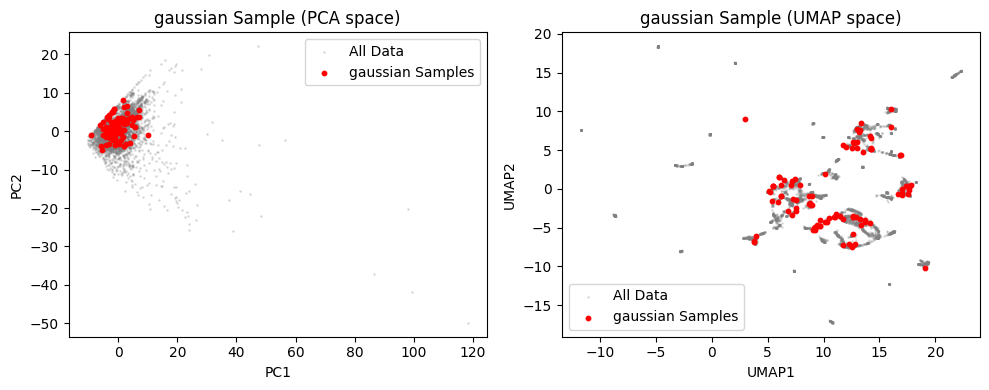

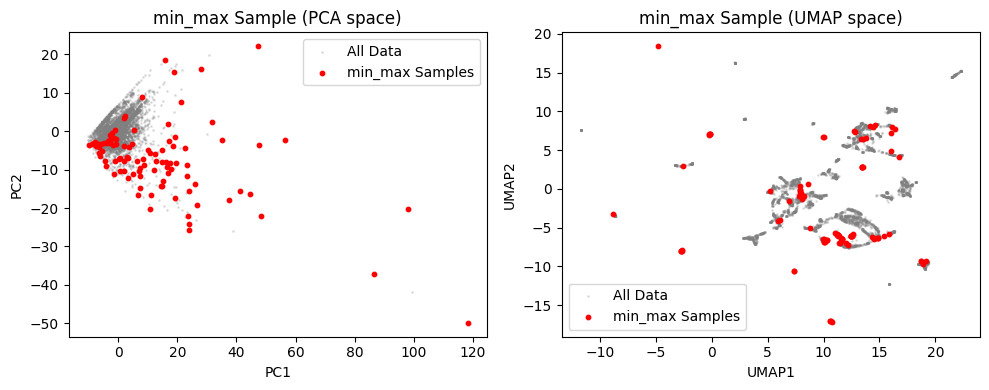

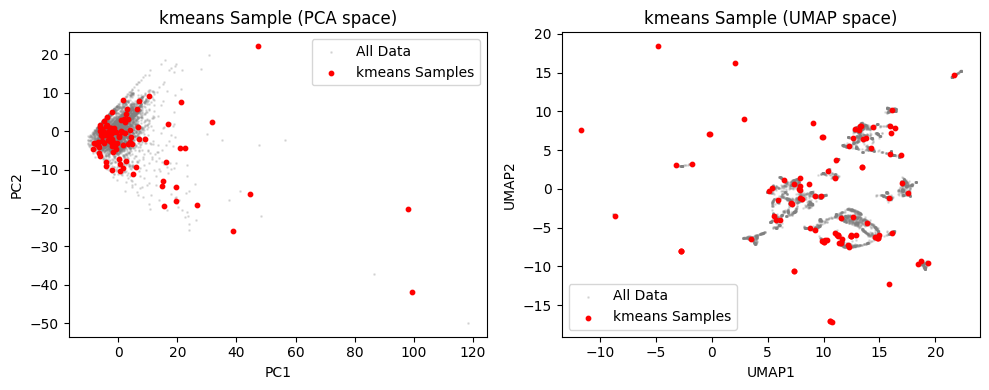

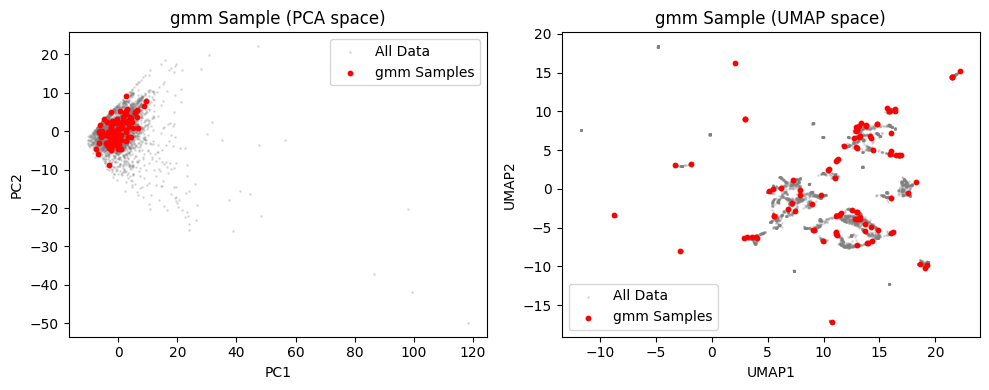

In [8]:
from odor_space_sampling import plot_all_sampling_methods

plot_all_sampling_methods(data, results)

## Getting the sampled molecules

To get the actual molecules selected by a method, use the `indices` from the results dict to look up rows in `data.df`.

In [10]:
# get the molecules selected by the GMM method
gmm_indices = results["gmm"]["indices"]
selected_odors = data.df.iloc[gmm_indices]
print(selected_odors)

# save to CSV
selected_odors.to_csv("../data/gmm_sampled_molecules.csv", index=False)

                      smiles              label       cid  \
2454         CCCCCCCCCC=CC=O           ['gslf']     20967   
5148     CCCCCCCCC=CCCCCCCCC          ['human']    521661   
4055    O=C1CCC=CCCCCCCCCCC1           ['gslf']     84545   
3120     CCCCCCCCCCCCC(C)C=O           ['gslf']  11790917   
1250              CCCc1ccco1  ['human', 'gslf']     77907   
...                      ...                ...       ...   
5081  CCCCCCCCCCCCCC=CC(=O)O           ['gslf']    152802   
3397             CSCCOC(C)=O           ['gslf']   4447651   
4369    CCOC(=O)CCCCCOC(C)=O           ['gslf']    113640   
4624  CCCCOC(=O)CCC(=O)OCCCC           ['gslf']      8830   
5015           CCCCCCC1OCCO1           ['gslf']     74360   

                              IUPAC  
2454                   dodec-2-enal  
5148                  octadec-9-ene  
4055       cyclopentadec-4-en-1-one  
3120           2-methyltetradecanal  
1250                  2-propylfuran  
...                             ...  
5

## Using a single sampling method

If you want to run and visualize just one method, you can import it directly. Each method returns `(samples, indices, distances)` and can be passed straight to `plot_sampling_projections`.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


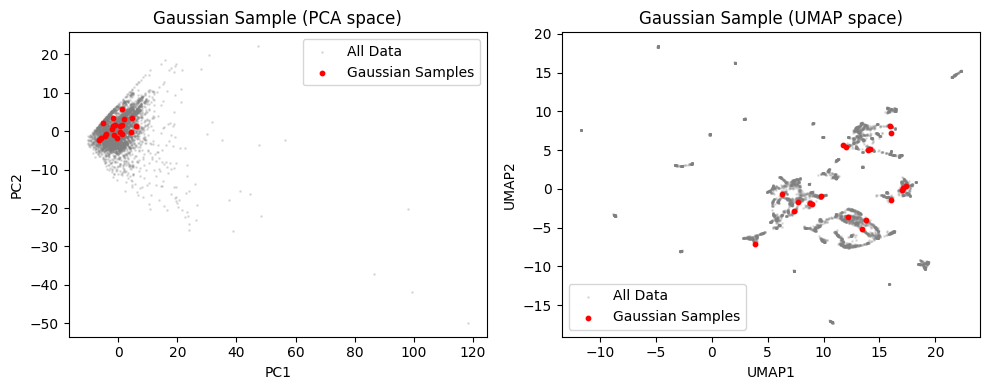

In [11]:
from odor_space_sampling.sampling import gaussian_sample
from odor_space_sampling import plot_sampling_projections

result = gaussian_sample(data.x, n_samples=20, seed=42)
plot_sampling_projections(data, result, label="Gaussian")

## Plotting with external indices

If you have a set of molecules from outside this package (e.g. a hand-curated list or indices from a reference table), you can pass them directly to `plot_sampling_projections` as a plain array.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


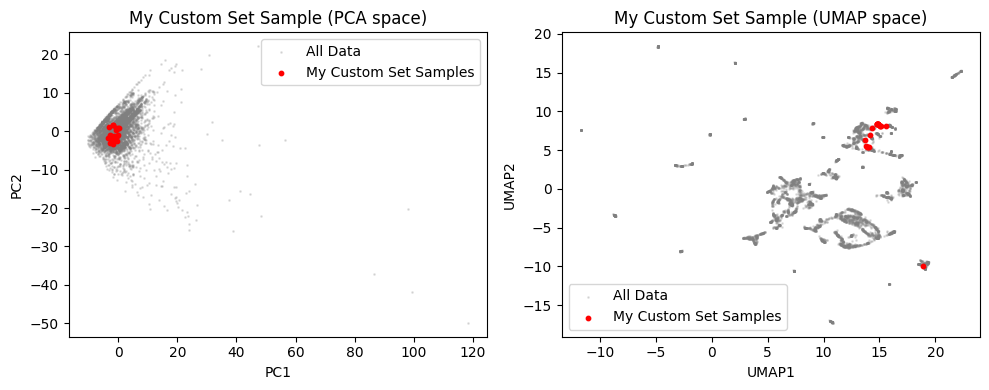

In [12]:
import numpy as np
from odor_space_sampling import plot_sampling_projections

# example: first 20 molecules in the dataset as a stand-in for external indices
my_indices = np.arange(20)
plot_sampling_projections(data, my_indices, label="My Custom Set")

## Comparing multiple sets side-by-side

Pass a list of `(result_or_indices, label)` pairs to `plot_sampling_projections` to compare any combination of methods and external sets in one call.

In [ ]:
from odor_space_sampling.sampling import gmm_sample, kmeans_sample
from odor_space_sampling import plot_sampling_projections
import numpy as np

gmm_result   = gmm_sample(data.x, n_samples=20, seed=42)
kmeans_result = kmeans_sample(data.x, n_samples=20, seed=42)
my_indices   = np.arange(20)

plot_sampling_projections(data, [
    (gmm_result,    "GMM"),
    (kmeans_result, "KMeans"),
    (my_indices,    "My Custom Set"),
    ([1, 2, 3], "My Other Custom Set")
])

## GMM sampling with more control

Before running GMM-based sampling you may want to find the best number of Gaussian components (`n_clusters`) for your dataset. `aic_and_bic_gmm` sweeps over a range of cluster counts, computes AIC, BIC, and KS statistics for each, and plots the results. The minimum AIC/BIC value suggests a good `n_clusters` to use.

**Note:** This fits one GMM per cluster count, so it can be slow. Keep `max_n_clusters` small (e.g. 20) while exploring.

In [ ]:
from odor_space_sampling import aic_and_bic_gmm
import numpy as np

aics, bics, ks_means, ks_meds = aic_and_bic_gmm(data, max_n_clusters=20, plot=True)

print(f"Best AIC:       {np.argmin(aics) + 1} clusters")
print(f"Best BIC:       {np.argmin(bics) + 1} clusters")
print(f"Best KS median: {np.argmin(ks_meds) + 1} clusters")

`get_n_closest_points_gmm` fits a GMM, samples from it, and returns the `n` nearest real odors to each sample point -- useful when you want a ranked shortlist around each sample.

In [ ]:
from odor_space_sampling import get_n_closest_points_gmm

closest = get_n_closest_points_gmm(
    data,
    n_closest_points=20,
    n_samples=100,
    n_clusters=120,
    seed=12345,
    save_path="../data/gmm_n_closest.csv"
)
print(closest)

      sample                   smiles              label      cid  \
0          0    CCCCCCCCCCCCCCCC(C)=O           ['gslf']    18027   
1          0    CCCCC=CCCCCCCCCCCCC=O           ['gslf']    94120   
2          0    CCCCCCCCC=CCCCCCCCC=O           ['gslf']    17029   
3          0     CCCCCCCCCCCCCCC(C)=O  ['human', 'gslf']    29251   
4          0    CCCCCCCCCCCCCCCC=CC=O           ['gslf']    41923   
...      ...                      ...                ...      ...   
1995      99          CCCCCCC1CCOC1=O           ['gslf']    86736   
1996      99  CC(C)=CCCC1(C)CCC(=O)O1           ['gslf']  9942315   
1997      99     CCCCCC=CCC1CCC(=O)O1           ['gslf']    62727   
1998      99       CCCCCCCC1CCC(=O)O1  ['human', 'gslf']     7714   
1999      99         CCCCC1OC(=O)CC1C           ['gslf']    62900   

                                                  IUPAC  
0                                      heptadecan-2-one  
1                                       octadec-13-enal

`gmm_resample_varying_seeds` fits a variety of GMM's to the data and samples from it -- useful for generating a lot of samples from different fitted gaussians

In [ ]:
from odor_space_sampling import gmm_resample_varying_seeds

dfs = gmm_resample_varying_seeds(
    data=data,
    seeds=np.arange(20),
    n_clusters=120,
    n_samples=100,
    save_path="../data/multiseed/gmm_multiseed"
)
print(dfs)

iterating through seeds: 100%|██████████| 20/20 [02:49<00:00,  8.45s/it]

None
